In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance

#keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16

from sklearn.utils import shuffle


In [9]:
test_dir = '/content/drive/MyDrive/MRIimages/Testing/'
train_dir = '/content/drive/MyDrive/MRIimages/Training/'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

**Data Visulization**


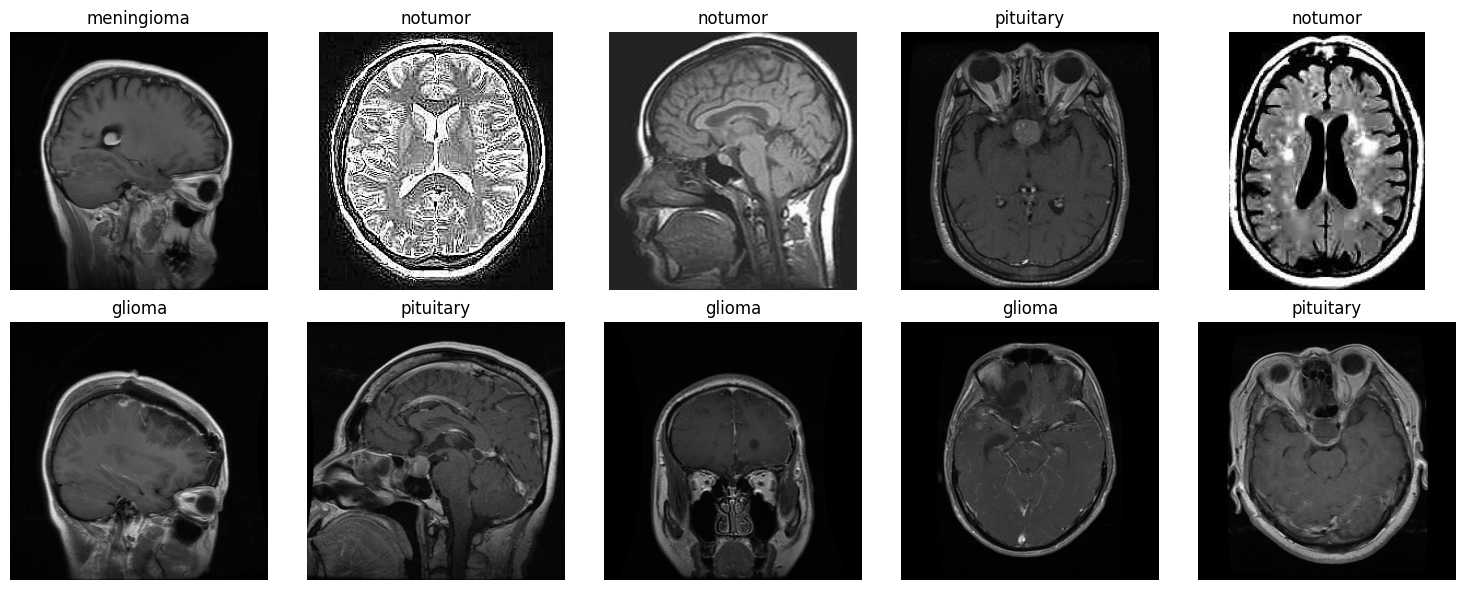

In [10]:
import matplotlib.pyplot as plt

#select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)
random_indices

#Create a figure to display images in rows
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, index in enumerate(random_indices):
  image_path = train_paths[index]
  image = Image.open(image_path)
  axes[i].imshow(image, cmap='gray')
  axes[i].set_title(train_labels[index])
  axes[i].axis('off')

plt.tight_layout()
plt.show()


**Image Processing**

In [11]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

**Model**


In [13]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1505s 5s/step - loss: 0.6443 - sparse_categorical_accuracy: 0.7430
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1441s 5s/step - loss: 0.2666 - sparse_categorical_accuracy: 0.9047
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1427s 5s/step - loss: 0.1656 - sparse_categorical_accuracy: 0.9391
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1420s 5s/step - loss: 0.1266 - sparse_categorical_accuracy: 0.9546
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 1466s 5s/step - loss: 0.1088 - sparse_categorical_accuracy: 0.9585


**Train and val plots**

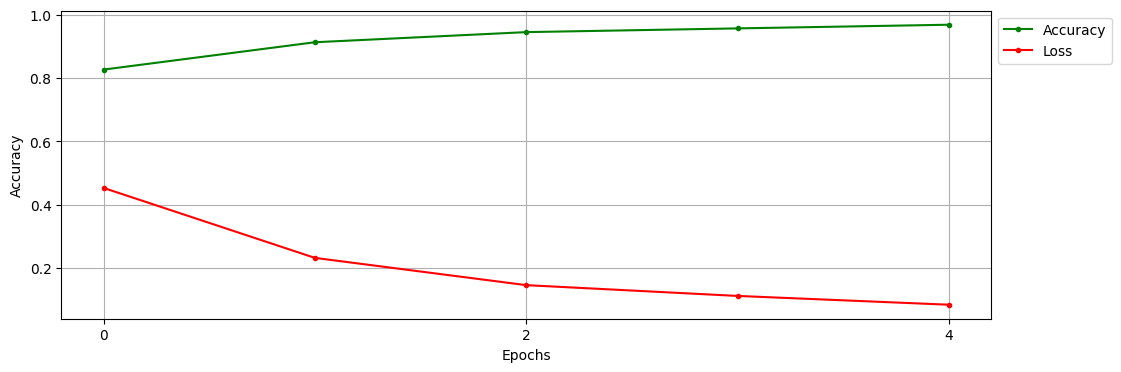

In [14]:
plt.figure(figsize=(12, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-',label='Training Accuracy')
plt.plot(history.history['loss'], '.r-',label='loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(range(0,epochs)[0::2])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor = (1,1))
plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np

test_images = open_images(test_paths)
test_labels = encode_label(test_labels)

test_predictions = model.predict(test_images)
print("Classification Report:")
print(classification_report(test_labels, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 275s 7s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       306
           1       0.97      0.86      0.91       300
           2       0.99      1.00      0.99       405
           3       0.89      0.99      0.94       300

    accuracy                           0.94      1311
   macro avg       0.93      0.93      0.93      1311
weighted avg       0.94      0.94      0.94      1311



Confusion Matrix:
[[269   7   4  26]
 [ 35 258   0   7]
 [  0   0 403   2]
 [  2   0   0 298]]


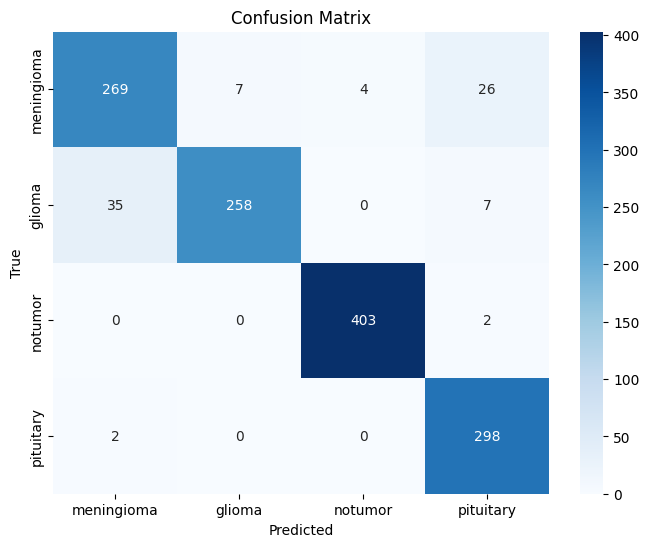

In [17]:
conf_matrix = confusion_matrix(test_labels, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

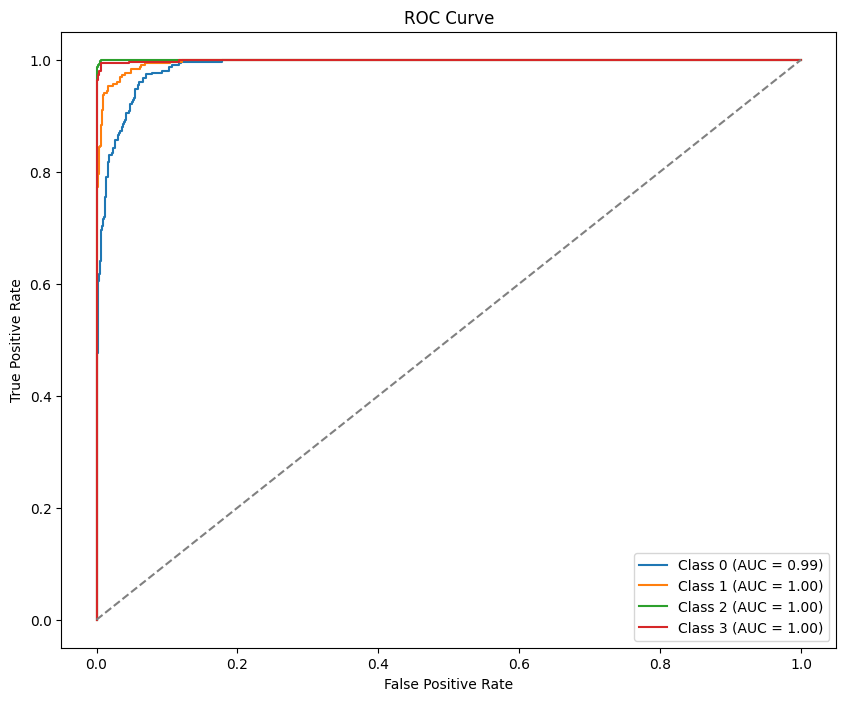

In [19]:
test_labels_bin = label_binarize(test_labels, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [20]:
model.save('model.h5')

In [21]:
from tensorflow.keras.models import load_model
model = load_model('model.h5')

**MRI Tumor Detection System**

In [25]:
from keras.preprocessing.image import load_img, img_to_array

class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(image_path, model):
  try:
    image = load_img(image_path, target_size=(128, 128))
    img_array = img_to_array(image)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    confidence_score = np.max(prediction, axis=1)[0]

    # determine the class
    if class_labels[predicted_class] == 'notumor':
          return 'Notumor'
    else:
          result = f"Tumor: {class_labels[predicted_class]}"

    plt.imshow(image)
    plt.axis('off')
    plt.title(f"{result} (Confidence: ) {confidence_score * 100:.2f}%")
    plt.show()

  except Exception as e:
      print(f"Error processing image: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


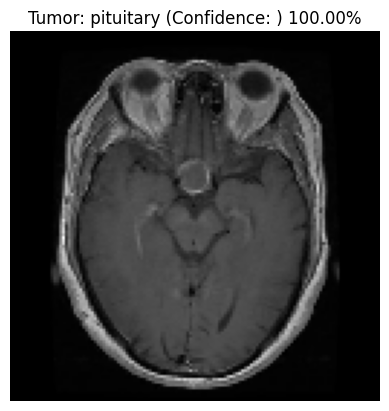

In [36]:
img_path = '/content/drive/MyDrive/MRIimages/Testing/pituitary/Te-pi_0064.jpg'

detect_and_display(img_path, model)